# RecruTap - Model Evaluation & Explainability

## Objective

This notebook evaluates the performance of the selected machine learning model for job fraud detection.

The objectives are:

- Load the trained Random Forest model
- Evaluate performance on unseen data
- Analyze classification metrics
- Visualize prediction performance
- Interpret model behavior
- Export evaluation results

The selected model - Random Forest will later be integrated into the RecruTap backend for real-time fraud detection.

## Import Required Libraries

Import the libraries required for model loading, evaluation and visualization.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import joblib

from sklearn.model_selection import train_test_split

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, 
    ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score)

## Load Processed Dataset

Load the processed dataset generated during the feature engineering stage.

The dataset contains:

- clean_text
- fraudulent

In [2]:
df = pd.read_csv("../data/processed/model_dataset.csv")

df.head()

,clean_text,fraudulent
0,marketing intern food weve created groundbreak...,0
1,customer service cloud video production second...,0
2,commissioning machinery assistant cma valor se...,0
3,account executive washington dc passion improv...,0
4,review manager spotsource solutions llc global...,0


## Load Saved Artifacts

Load the trained TF-IDF vectorizer and the selected production model.

The Random Forest classifier was chosen based on its superior performance during model comparison.

In [3]:
vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

best_model = joblib.load("../models/fraud_detector.pkl")

## Define Features and Target

Feature:

- clean_text

Target:

- fraudulent

In [4]:
X = df["clean_text"]

y = df["fraudulent"]

## Vectorize Text

Transform textual features into numerical TF-IDF vectors using the trained vectorizer.

In [5]:
X = vectorizer.transform(X)

## Split Dataset

Separate the dataset into training and testing subsets using stratified sampling.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Generate Predictions

Use the trained Random Forest classifier to predict labels for unseen job postings.

In [7]:
predictions = best_model.predict(X_test)

## Performance Metrics

The model is evaluated using multiple classification metrics to obtain a comprehensive assessment of prediction quality.

These include:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

In [8]:
accuracy = accuracy_score(y_test,predictions)

precision = precision_score(y_test,predictions)

recall = recall_score(y_test,predictions)

f1 = f1_score(y_test,predictions)

roc = roc_auc_score(y_test,predictions)

print("Accuracy :",accuracy)

print("Precision :",precision)

print("Recall :",recall)

print("F1 Score :",f1)

print("ROC AUC :",roc)

Accuracy : 0.9832214765100671
Precision : 0.991304347826087
Recall : 0.6589595375722543
F1 Score : 0.7916666666666666
ROC AUC : 0.829332839605992


In [9]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.99      0.66      0.79       173

    accuracy                           0.98      3576
   macro avg       0.99      0.83      0.89      3576
weighted avg       0.98      0.98      0.98      3576



## Confusion Matrix

The confusion matrix summarizes model predictions by comparing predicted labels with actual labels.

This visualization highlights correct classifications as well as false positives and false negatives.

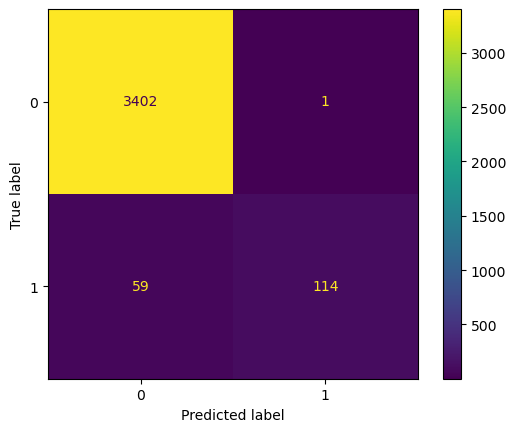

In [10]:
cm = confusion_matrix(y_test, predictions)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.show()

## ROC Curve

The ROC curve illustrates the trade-off between the true positive rate and false positive rate across different classification thresholds.

The Area Under the Curve (AUC) provides an overall measure of classifier performance.

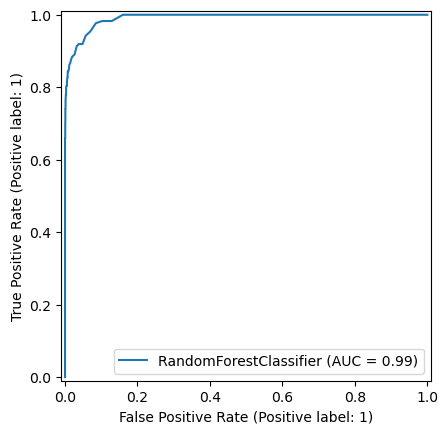

In [11]:
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.show()

In [12]:
report = pd.DataFrame({"Metric":["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
                       "Score":[accuracy, precision, recall, f1, roc]})

report

,Metric,Score
0,Accuracy,0.983221
1,Precision,0.991304
2,Recall,0.658960
3,F1 Score,0.791667
4,ROC AUC,0.829333


In [ ]:
report.to_csv( "../reports/model_metrics.csv", index=False)

## Discussion

The Random Forest classifier demonstrated the strongest predictive performance among the evaluated models and was selected as the final production model.

Its ability to capture complex relationships between textual features makes it well suited for detecting fraudulent recruitment patterns.

# Conclusion

In this notebook:

- The selected Random Forest model was evaluated on unseen data.
- Classification performance was assessed using multiple evaluation metrics.
- Evaluation results were exported for future reference.

The trained model is now ready to be integrated into the RecruTap FastAPI backend for real-time fraud prediction.